In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

COLORS = {
    "primary":   "#2E4057",
    "secondary": "#048A81",
    "accent":    "#54C6EB",
    "warm":      "#E76F51",
    "gray":      "#6C757D",
    "light":     "#F4F1DE",
}

SUBTYPE_COLORS = {
    "LumA":        "#048A81",
    "LumB":        "#54C6EB",
    "Her2":        "#E76F51",
    "Basal":       "#2E4057",
    "claudin-low": "#F4A261",
    "Normal":      "#6C757D",
}

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
})

In [2]:
df = pd.read_csv("../data/processed/clinical_clean.csv")
print(f"Shape: {df.shape}")
print(f"OS event rate: {df['os_event'].mean():.1%}")
print(f"Median follow-up: {df['os_months'].median():.1f} months")
df.head()

Shape: (496, 17)
OS event rate: 41.9%
Median follow-up: 93.9 months


,patientId,os_months,os_event,rfs_months,rfs_event,age,grade,tumor_size,lymph_nodes,npi,subtype,er,her2,pr,chemo,hormone_tx,stage
0,MB-0122,138.900000,0,138.900000,0,58.95,1.0,20.0,1.0,3.040,LumA,Positive,Negative,Positive,NO,YES,2.0
1,MB-0262,182.266667,1,182.266667,0,55.44,3.0,26.0,0.0,4.052,Her2,Positive,Negative,Negative,NO,YES,2.0
2,MB-0514,13.400000,0,13.400000,0,42.89,2.0,20.0,1.0,4.040,LumB,Positive,Negative,Positive,YES,YES,2.0
3,MB-0317,151.666667,1,151.666667,0,76.68,3.0,39.0,0.0,4.078,LumA,Positive,Negative,Positive,NO,NO,NaN
4,MB-0288,63.800000,1,63.800000,1,55.22,2.0,30.0,25.0,5.060,Normal,Positive,Positive,Negative,YES,YES,2.0


## Kaplan-Meier Survival Analysis

Kaplan-Meier curves estimate the survival function from time-to-event data, 
accounting for censored observations (patients lost to follow-up or alive at 
last contact). Log-rank tests assess whether survival differences between 
groups are statistically significant.

We examine overall survival stratified by:
- **Molecular subtype** (LumA, LumB, HER2, Basal, claudin-low, Normal)
- **ER status** (Positive vs Negative)
- **Hormone therapy** (received vs not received)

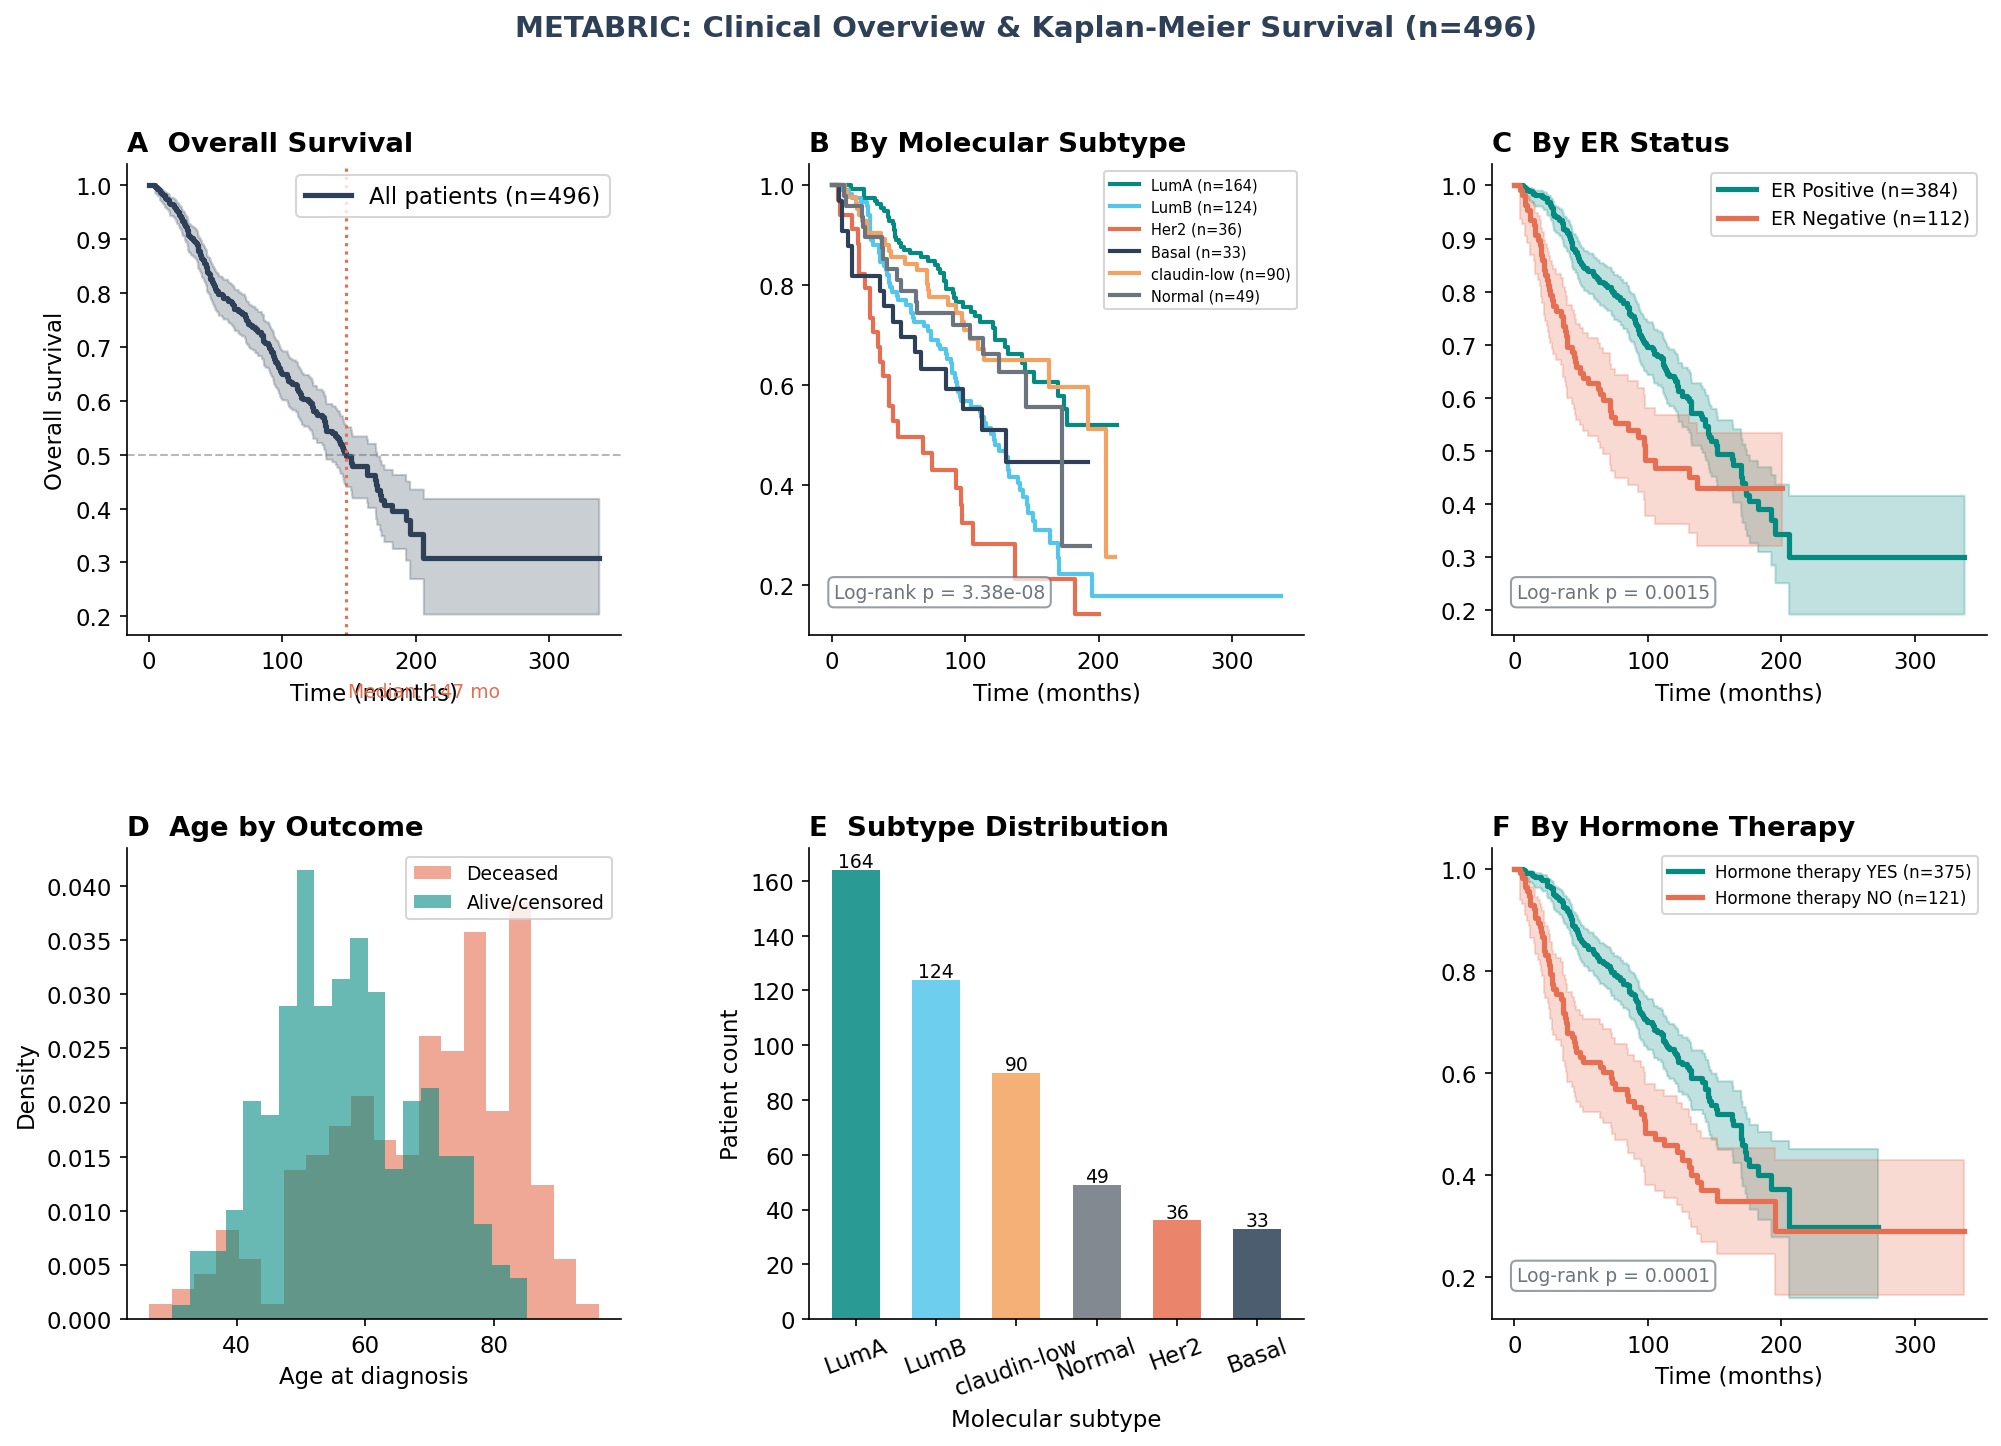

In [5]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# Panel A — Overall KM
ax0 = fig.add_subplot(gs[0, 0])
kmf = KaplanMeierFitter()
kmf.fit(df["os_months"], event_observed=df["os_event"],
        label=f"All patients (n={len(df)})")
kmf.plot_survival_function(ax=ax0, ci_show=True, color=COLORS["primary"], lw=2.5)
median_os = kmf.median_survival_time_
ax0.axhline(0.5, color=COLORS["gray"], ls="--", lw=1, alpha=0.5)
ax0.axvline(median_os, color=COLORS["warm"], ls=":", lw=1.5)
ax0.text(median_os + 2, 0.05, f"Median: {median_os:.0f} mo",
         color=COLORS["warm"], fontsize=9)
ax0.set_xlabel("Time (months)")
ax0.set_ylabel("Overall survival")
ax0.set_title("A  Overall Survival", fontweight="bold", loc="left")

# Panel B — KM by molecular subtype
ax1 = fig.add_subplot(gs[0, 1])
groups = df.dropna(subset=["subtype"])
for subtype, color in SUBTYPE_COLORS.items():
    mask = groups["subtype"] == subtype
    if mask.sum() < 5:
        continue
    kmf2 = KaplanMeierFitter()
    kmf2.fit(groups.loc[mask, "os_months"], groups.loc[mask, "os_event"],
             label=f"{subtype} (n={mask.sum()})")
    kmf2.plot_survival_function(ax=ax1, ci_show=False, color=color, lw=2)

res = multivariate_logrank_test(groups["os_months"], groups["subtype"], groups["os_event"])
ax1.text(0.05, 0.08, f"Log-rank p = {res.p_value:.2e}",
         transform=ax1.transAxes, fontsize=9, color=COLORS["gray"],
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=COLORS["gray"], alpha=0.7))
ax1.set_xlabel("Time (months)")
ax1.set_ylabel("")
ax1.set_title("B  By Molecular Subtype", fontweight="bold", loc="left")
ax1.legend(fontsize=7, loc="upper right")

# Panel C — KM by ER status
ax2 = fig.add_subplot(gs[0, 2])
for er_val, color in [("Positive", COLORS["secondary"]), ("Negative", COLORS["warm"])]:
    mask = df["er"] == er_val
    if mask.sum() < 5:
        continue
    kmf3 = KaplanMeierFitter()
    kmf3.fit(df.loc[mask, "os_months"], df.loc[mask, "os_event"],
             label=f"ER {er_val} (n={mask.sum()})")
    kmf3.plot_survival_function(ax=ax2, ci_show=True, color=color, lw=2.5)

er_pos = df[df["er"] == "Positive"]
er_neg = df[df["er"] == "Negative"]
res_er = logrank_test(er_pos["os_months"], er_neg["os_months"],
                      er_pos["os_event"],  er_neg["os_event"])
ax2.text(0.05, 0.08, f"Log-rank p = {res_er.p_value:.4f}",
         transform=ax2.transAxes, fontsize=9, color=COLORS["gray"],
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=COLORS["gray"], alpha=0.7))
ax2.set_xlabel("Time (months)")
ax2.set_ylabel("")
ax2.set_title("C  By ER Status", fontweight="bold", loc="left")
ax2.legend(fontsize=9)

# Panel D — Age distribution by outcome
ax3 = fig.add_subplot(gs[1, 0])
for event, label, color in [(1, "Deceased", COLORS["warm"]),
                             (0, "Alive/censored", COLORS["secondary"])]:
    ax3.hist(df.loc[df["os_event"] == event, "age"], bins=20,
             alpha=0.6, color=color, label=label, density=True)
ax3.set_xlabel("Age at diagnosis")
ax3.set_ylabel("Density")
ax3.set_title("D  Age by Outcome", fontweight="bold", loc="left")
ax3.legend(fontsize=9)

# Panel E — Subtype distribution
ax4 = fig.add_subplot(gs[1, 1])
subtype_counts = df["subtype"].value_counts()
colors_bar = [SUBTYPE_COLORS.get(s, COLORS["gray"]) for s in subtype_counts.index]
bars = ax4.bar(subtype_counts.index, subtype_counts.values,
               color=colors_bar, alpha=0.85, width=0.6)
for bar, val in zip(bars, subtype_counts.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha="center", fontsize=9)
ax4.set_xlabel("Molecular subtype")
ax4.set_ylabel("Patient count")
ax4.set_title("E  Subtype Distribution", fontweight="bold", loc="left")
ax4.tick_params(axis="x", rotation=20)

# Panel F — KM by hormone therapy
ax5 = fig.add_subplot(gs[1, 2])
for ht_val, color in [("YES", COLORS["secondary"]), ("NO", COLORS["warm"])]:
    mask = df["hormone_tx"] == ht_val
    if mask.sum() < 5:
        continue
    kmf4 = KaplanMeierFitter()
    kmf4.fit(df.loc[mask, "os_months"], df.loc[mask, "os_event"],
             label=f"Hormone therapy {ht_val} (n={mask.sum()})")
    kmf4.plot_survival_function(ax=ax5, ci_show=True, color=color, lw=2.5)

ht_yes = df[df["hormone_tx"] == "YES"]
ht_no  = df[df["hormone_tx"] == "NO"]
res_ht = logrank_test(ht_yes["os_months"], ht_no["os_months"],
                      ht_yes["os_event"],  ht_no["os_event"])
ax5.text(0.05, 0.08, f"Log-rank p = {res_ht.p_value:.4f}",
         transform=ax5.transAxes, fontsize=9, color=COLORS["gray"],
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=COLORS["gray"], alpha=0.7))
ax5.set_xlabel("Time (months)")
ax5.set_ylabel("")
ax5.set_title("F  By Hormone Therapy", fontweight="bold", loc="left")
ax5.legend(fontsize=8)

fig.suptitle("METABRIC: Clinical Overview & Kaplan-Meier Survival (n=496)",
             fontsize=14, fontweight="bold", color=COLORS["primary"])

plt.savefig("../notebooks/figures/fig1_km_overview.png",
            bbox_inches="tight", dpi=150, facecolor="white")
plt.show()

### Key Findings

- **Median overall survival: ~150 months** (~12.5 years) for the full cohort
- **Molecular subtype is the strongest prognosticator** (log-rank p < 1e-08): 
  LumA has the best prognosis; Basal and Her2 subtypes show the worst survival
- **ER negative patients have significantly worse survival** (log-rank p = 0.0015),
  consistent with clinical literature
- **Hormone therapy is associated with improved survival** (log-rank p = 0.0001),
  though this is confounded by ER status — most ER+ patients receive hormone therapy

## Cox Proportional Hazards Model

The Cox PH model estimates the effect of multiple clinical variables on survival 
simultaneously, controlling for confounders. It outputs **hazard ratios (HR)**:
- HR > 1 → increased risk of death
- HR < 1 → protective effect
- We report 95% confidence intervals and p-values for each feature.

In [6]:
from lifelines import CoxPHFitter

cox_df = df[["os_months", "os_event", "age", "grade", "tumor_size",
             "lymph_nodes", "npi", "er", "her2", "chemo", "hormone_tx"]].copy()

# Encode categoricals
cox_df["er_bin"]       = (cox_df["er"] == "Positive").astype(int)
cox_df["her2_bin"]     = (cox_df["her2"] == "Positive").astype(int)
cox_df["chemo_bin"]    = (cox_df["chemo"] == "YES").astype(int)
cox_df["hormone_bin"]  = (cox_df["hormone_tx"] == "YES").astype(int)

cox_features = ["age", "grade", "tumor_size", "lymph_nodes",
                "er_bin", "her2_bin", "chemo_bin", "hormone_bin"]

cox_clean = cox_df[["os_months", "os_event"] + cox_features].dropna()
print(f"Cox dataset: {cox_clean.shape}")

cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_clean, duration_col="os_months", event_col="os_event")
cph.print_summary()
print(f"\nC-index: {cph.concordance_index_:.3f}")

Cox dataset: (445, 10)


<lifelines.CoxPHFitter: fitted with 445 total observations, 257 right-censored observations>
             duration col = 'os_months'
                event col = 'os_event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 445
number of events observed = 188
   partial log-likelihood = -973.08
         time fit was run = 2026-05-13 15:45:41 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
age          0.04      1.04      0.01            0.03            0.05                1.03                1.05
grade        0.27      1.30      0.11            0.05            0.48                1.05                1.62
tumor_size   0.01      1.01      0.00            0.00            0.01                1.00                1.01
lymph_nodes  0.05      1.05      0.01            0.02            0.07                1.02                1.07
er_bin      -0.34      0.71      0.19           -0.72            0.04                0.49                1.04
her2_bin     0.27      1.31      0.21           -0.15            0.69                0.86                1.99
chemo_bin    0.12      1.13      0.17           -0.20            0.45                0.82                1.57
hormone_bin -0.41      0.66      0.18           -0.77           -0.05                0.46                0.95

             cmp to     z      p  -log2(p)
covariate                                 
age            0.00  7.09 <0.005     39.40
grade          0.00  2.41   0.02      5.96
tumor_size     0.00  2.37   0.02      5.83
lymph_nodes    0.00  3.72 <0.005     12.30
er_bin         0.00 -1.73   0.08      3.59
her2_bin       0.00  1.26   0.21      2.27
chemo_bin      0.00  0.74   0.46      1.12
hormone_bin    0.00 -2.26   0.02      5.38
---
Concordance = 0.76
Partial AIC = 1962.16
log-likelihood ratio test = 122.36 on 8 df
-log2(p) of ll-ratio test = 72.98


C-index: 0.758


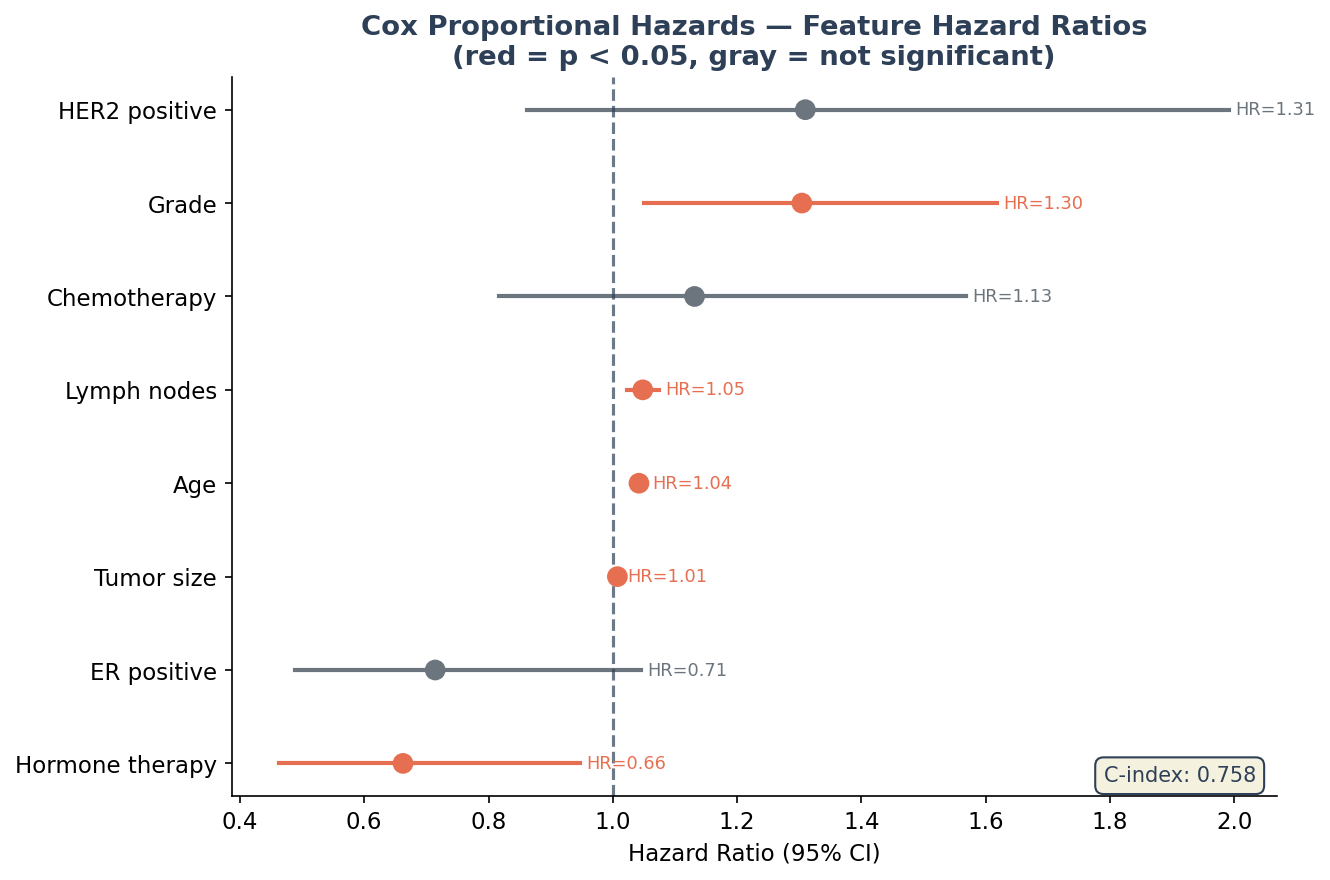

In [7]:
fig2, ax = plt.subplots(figsize=(9, 6))
fig2.patch.set_facecolor("white")

summary = cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].copy()
summary.index = ["Age", "Grade", "Tumor size", "Lymph nodes",
                 "ER positive", "HER2 positive", "Chemotherapy", "Hormone therapy"]
summary = summary.sort_values("exp(coef)")

colors_forest = [COLORS["warm"] if p < 0.05 else COLORS["gray"] for p in summary["p"]]

y_pos = range(len(summary))
ax.scatter(summary["exp(coef)"], y_pos, color=colors_forest, s=80, zorder=3)
for i, (_, row) in enumerate(summary.iterrows()):
    color = COLORS["warm"] if row["p"] < 0.05 else COLORS["gray"]
    ax.plot([row["exp(coef) lower 95%"], row["exp(coef) upper 95%"]], [i, i],
            color=color, lw=2, zorder=2)

ax.axvline(1.0, color=COLORS["primary"], ls="--", lw=1.5, alpha=0.7)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(summary.index)
ax.set_xlabel("Hazard Ratio (95% CI)")
ax.set_title("Cox Proportional Hazards — Feature Hazard Ratios\n"
             "(red = p < 0.05, gray = not significant)",
             fontweight="bold", color=COLORS["primary"])

for i, (_, row) in enumerate(summary.iterrows()):
    ax.text(row["exp(coef) upper 95%"] + 0.01, i,
            f"HR={row['exp(coef)']:.2f}", va="center", fontsize=8.5,
            color=COLORS["warm"] if row["p"] < 0.05 else COLORS["gray"])

ax.text(0.98, 0.02, f"C-index: {cph.concordance_index_:.3f}",
        transform=ax.transAxes, ha="right", fontsize=10, color=COLORS["primary"],
        bbox=dict(boxstyle="round,pad=0.4", fc=COLORS["light"], ec=COLORS["primary"]))

plt.tight_layout()
plt.savefig("../notebooks/figures/fig2_cox_forest.png",
            bbox_inches="tight", dpi=150, facecolor="white")
plt.show()

### Key Findings

- **C-index: 0.758** — good discriminative ability for a clinical-only model
- **Age** (HR=1.04, p<0.005) and **lymph nodes** (HR=1.05, p<0.005) are the 
  strongest independent adverse prognostic factors
- **Hormone therapy** (HR=0.66, p=0.02) shows a significant protective effect,
  consistent with its established role in ER+ breast cancer treatment
- **Grade** (HR=1.30, p=0.02) and **tumor size** (HR=1.01, p=0.02) are 
  independently significant — meaning their effect on survival holds even after 
  controlling for all other variables in the model
- **ER status** is significant in univariate analysis (KM, p=0.0015) but loses 
  significance in the multivariable Cox model (HR=0.71, p=0.08) — suggesting its 
  effect is largely mediated by hormone therapy, which most ER+ patients receive
- **HER2 and chemotherapy** are not independently prognostic in this cohort,
  possibly reflecting the limited sample size for HER2+ patients (n=36)

## ML-Based Prediction of 5-Year Survival

We frame survival prediction as a binary classification problem: 
did the patient die within 5 years (60 months)?  
Three models are compared using ROC-AUC on a held-out test set (25%).  
Feature importance is assessed via permutation importance.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

CUTOFF = 60  # 5 years in months

ml_df = cox_clean.copy()
ml_df["died_5yr"] = ((ml_df["os_months"] <= CUTOFF) & (ml_df["os_event"] == 1)).astype(int)

print(f"5-year mortality rate: {ml_df['died_5yr'].mean():.1%}")
print(f"Positive class (died within 5yr): {ml_df['died_5yr'].sum()}")

features = ["age", "grade", "tumor_size", "lymph_nodes",
            "er_bin", "her2_bin", "chemo_bin", "hormone_bin"]

X = ml_df[features]
y = ml_df["died_5yr"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, random_state=42),
}

aucs = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    proba = model.predict_proba(X_test_s)[:, 1]
    aucs[name] = roc_auc_score(y_test, proba)
    print(f"{name}: AUC = {aucs[name]:.3f}")

5-year mortality rate: 20.9%
Positive class (died within 5yr): 93
Logistic Regression: AUC = 0.826
Random Forest: AUC = 0.837
Gradient Boosting: AUC = 0.807


Best model: Random Forest


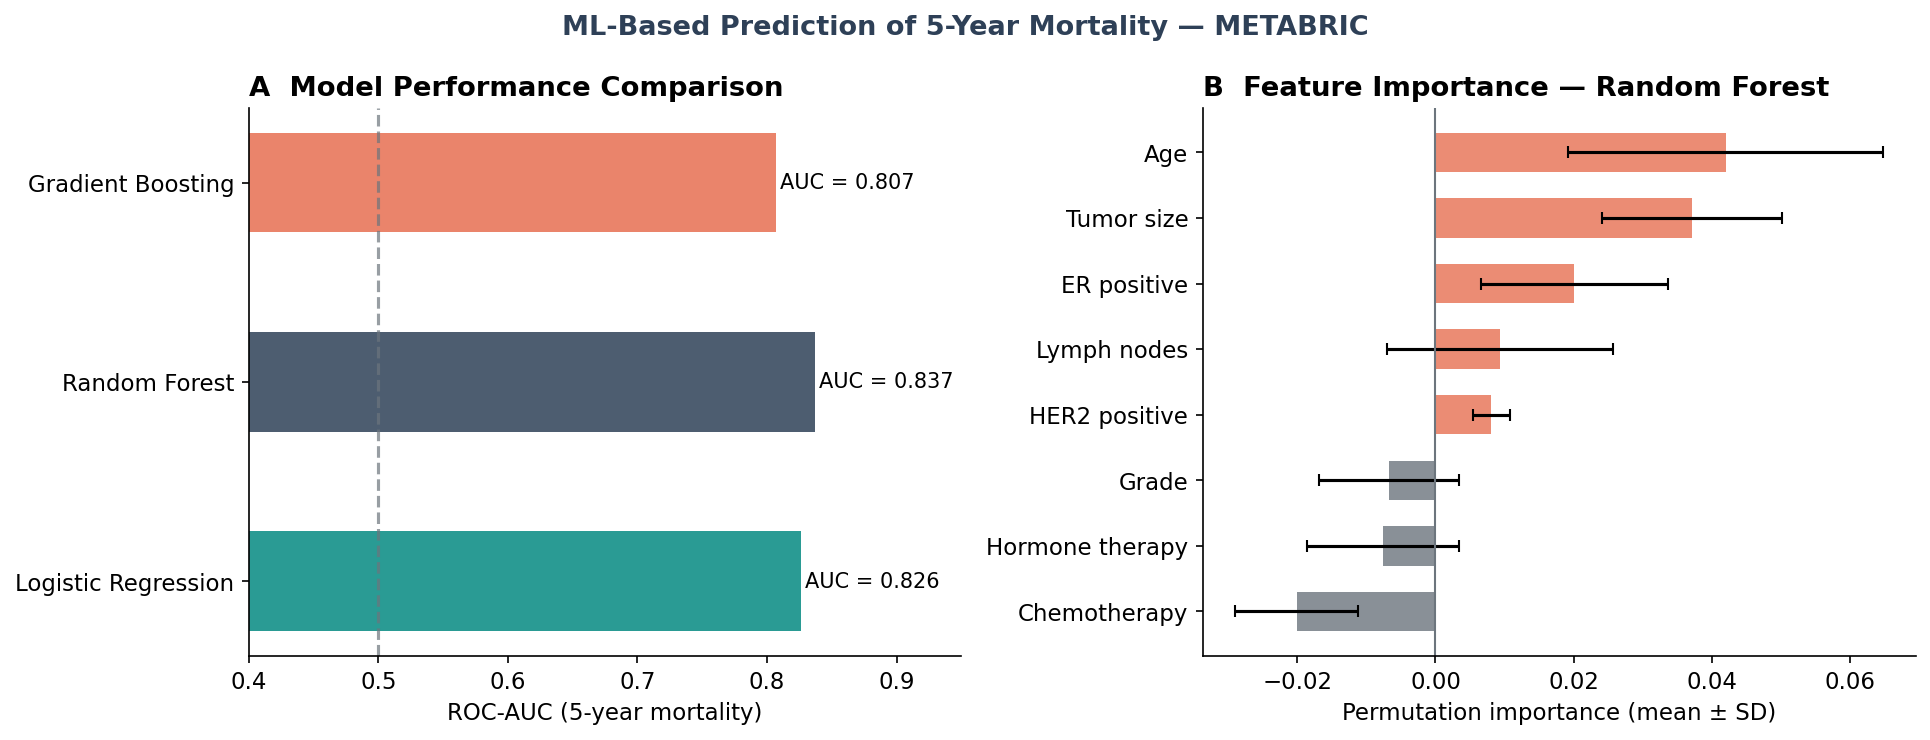

In [10]:
feat_labels = ["Age", "Grade", "Tumor size", "Lymph nodes",
               "ER positive", "HER2 positive", "Chemotherapy", "Hormone therapy"]

best_name = max(aucs, key=aucs.get)
best_model = models[best_name]
print(f"Best model: {best_name}")

perm = permutation_importance(best_model, X_test_s, y_test,
                               n_repeats=20, random_state=42)
imp_df = pd.DataFrame({
    "feature":    feat_labels,
    "importance": perm.importances_mean,
    "std":        perm.importances_std
}).sort_values("importance")

fig3, axes = plt.subplots(1, 2, figsize=(13, 5))
fig3.patch.set_facecolor("white")

# Panel A — AUC comparison
ax_auc = axes[0]
bar_colors = [COLORS["secondary"], COLORS["primary"], COLORS["warm"]]
bars = ax_auc.barh(list(aucs.keys()), list(aucs.values()),
                   color=bar_colors, alpha=0.85, height=0.5)
ax_auc.axvline(0.5, color=COLORS["gray"], ls="--", lw=1.5, alpha=0.7)
for bar, val in zip(bars, aucs.values()):
    ax_auc.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f"AUC = {val:.3f}", va="center", fontsize=10)
ax_auc.set_xlim(0.4, 0.95)
ax_auc.set_xlabel("ROC-AUC (5-year mortality)")
ax_auc.set_title("A  Model Performance Comparison", fontweight="bold", loc="left")

# Panel B — Feature importance
ax_imp = axes[1]
colors_imp = [COLORS["warm"] if v > 0 else COLORS["gray"] for v in imp_df["importance"]]
ax_imp.barh(imp_df["feature"], imp_df["importance"], xerr=imp_df["std"],
            color=colors_imp, alpha=0.8, height=0.6, capsize=3)
ax_imp.axvline(0, color=COLORS["gray"], lw=1)
ax_imp.set_xlabel("Permutation importance (mean ± SD)")
ax_imp.set_title(f"B  Feature Importance — {best_name}", fontweight="bold", loc="left")

fig3.suptitle("ML-Based Prediction of 5-Year Mortality — METABRIC",
              fontsize=13, fontweight="bold", color=COLORS["primary"])

plt.tight_layout()
plt.savefig("../notebooks/figures/fig3_ml_prediction.png",
            bbox_inches="tight", dpi=150, facecolor="white")
plt.show()

### Key Findings

- **Random Forest achieves the best AUC: 0.837** — strong performance using 
  clinical features only (no genomic data)
- All three models outperform random chance substantially, confirming that 
  clinical variables alone carry significant prognostic signal
- **Age and tumor size are the top predictors** in the Random Forest — consistent 
  with the Cox model results
- **Chemotherapy shows negative permutation importance** — likely reflecting 
  confounding: sicker patients (higher risk) are more likely to receive chemo, 
  so the model associates chemo with worse outcomes even though it may be beneficial
- **Grade and hormone therapy** have low importance in the RF despite being 
  significant in Cox — the two methods capture different aspects of feature relevance

## Addressing Confounding by Indication: Chemotherapy Subgroup Analysis

In observational data, chemotherapy is preferentially given to higher-risk patients
(larger tumors, higher grade, node-positive). This **confounding by indication** 
makes it appear harmful in naive models. 

To partially address this, we stratify by risk profile and examine the association 
between chemotherapy and 5-year mortality within clinically homogeneous subgroups.

High-risk subgroup (grade 3 + node positive): n=141
Chemo YES: 74 | Chemo NO: 67
5-year mortality - Chemo YES: 32.4%
5-year mortality - Chemo NO:  43.3%


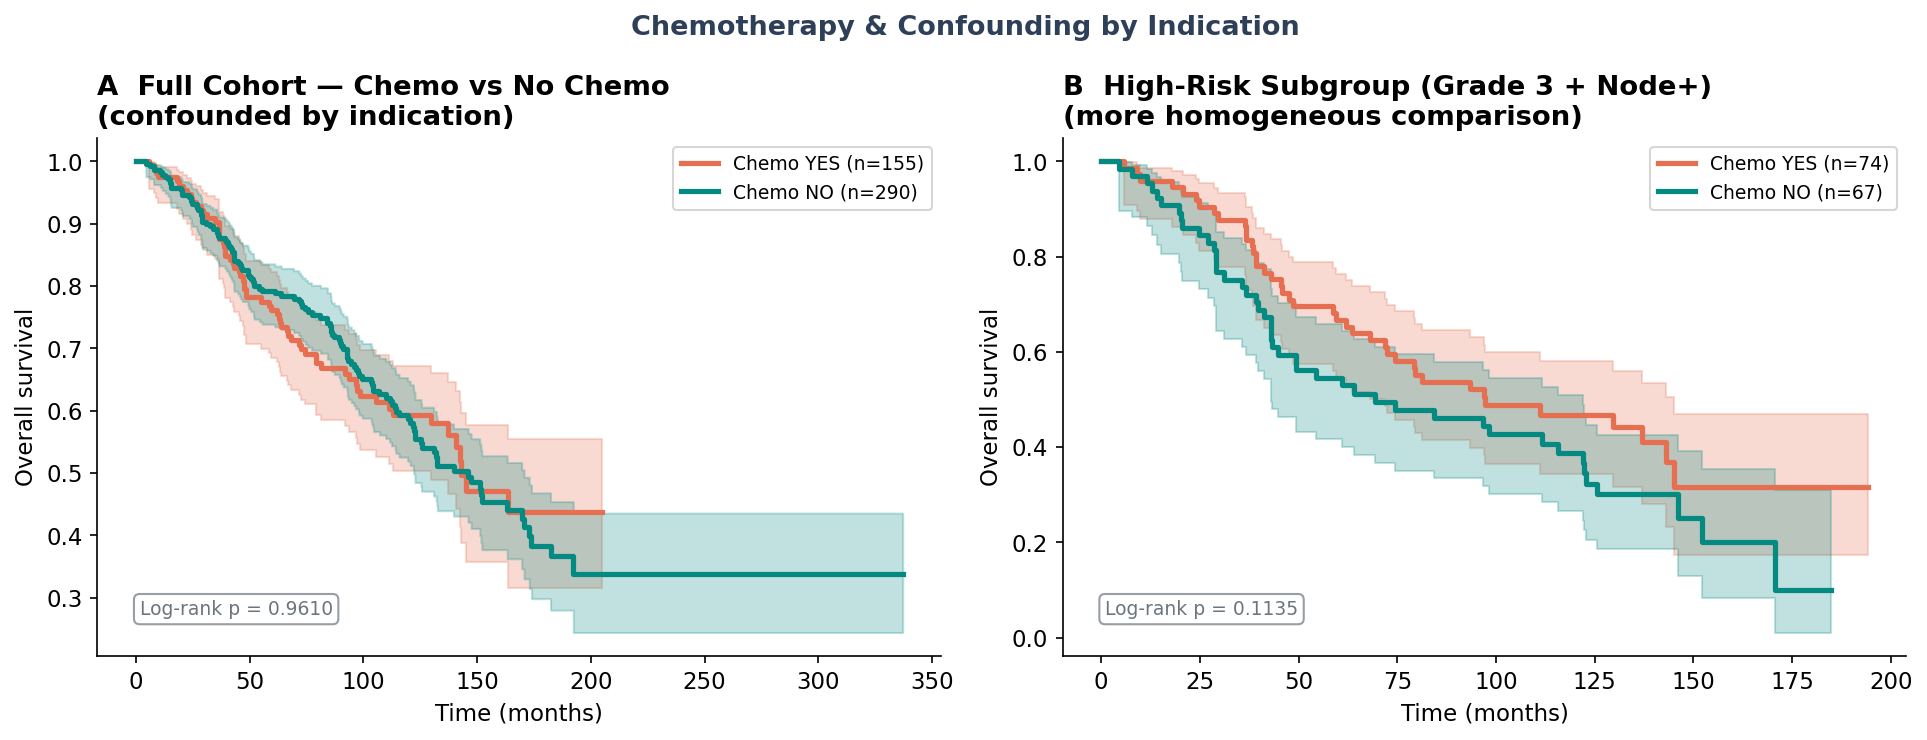

In [11]:
# Define high-risk subgroup: grade 3 AND lymph nodes > 0
high_risk = cox_clean[(cox_clean["grade"] == 3) & (cox_clean["lymph_nodes"] > 0)].copy()
high_risk["died_5yr"] = ((high_risk["os_months"] <= 60) & (high_risk["os_event"] == 1)).astype(int)

print(f"High-risk subgroup (grade 3 + node positive): n={len(high_risk)}")
print(f"Chemo YES: {(high_risk['chemo_bin']==1).sum()} | Chemo NO: {(high_risk['chemo_bin']==0).sum()}")
print(f"5-year mortality - Chemo YES: {high_risk[high_risk['chemo_bin']==1]['died_5yr'].mean():.1%}")
print(f"5-year mortality - Chemo NO:  {high_risk[high_risk['chemo_bin']==0]['died_5yr'].mean():.1%}")

# KM curves within high-risk subgroup
fig4, axes = plt.subplots(1, 2, figsize=(13, 5))
fig4.patch.set_facecolor("white")

# Panel A — full cohort KM by chemo
ax_full = axes[0]
for chemo_val, label, color in [(1, "Chemo YES", COLORS["warm"]),
                                 (0, "Chemo NO",  COLORS["secondary"])]:
    mask = cox_clean["chemo_bin"] == chemo_val
    kmf_c = KaplanMeierFitter()
    kmf_c.fit(cox_clean.loc[mask, "os_months"], cox_clean.loc[mask, "os_event"],
              label=f"{label} (n={mask.sum()})")
    kmf_c.plot_survival_function(ax=ax_full, ci_show=True, color=color, lw=2.5)

chemo_yes = cox_clean[cox_clean["chemo_bin"] == 1]
chemo_no  = cox_clean[cox_clean["chemo_bin"] == 0]
res_chemo = logrank_test(chemo_yes["os_months"], chemo_no["os_months"],
                         chemo_yes["os_event"],  chemo_no["os_event"])
ax_full.text(0.05, 0.08, f"Log-rank p = {res_chemo.p_value:.4f}",
             transform=ax_full.transAxes, fontsize=9, color=COLORS["gray"],
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=COLORS["gray"], alpha=0.7))
ax_full.set_xlabel("Time (months)")
ax_full.set_ylabel("Overall survival")
ax_full.set_title("A  Full Cohort — Chemo vs No Chemo\n(confounded by indication)",
                  fontweight="bold", loc="left")
ax_full.legend(fontsize=9)

# Panel B — high-risk subgroup KM by chemo
ax_hr = axes[1]
for chemo_val, label, color in [(1, "Chemo YES", COLORS["warm"]),
                                 (0, "Chemo NO",  COLORS["secondary"])]:
    mask = high_risk["chemo_bin"] == chemo_val
    if mask.sum() < 5:
        continue
    kmf_hr = KaplanMeierFitter()
    kmf_hr.fit(high_risk.loc[mask, "os_months"], high_risk.loc[mask, "os_event"],
               label=f"{label} (n={mask.sum()})")
    kmf_hr.plot_survival_function(ax=ax_hr, ci_show=True, color=color, lw=2.5)

hr_yes = high_risk[high_risk["chemo_bin"] == 1]
hr_no  = high_risk[high_risk["chemo_bin"] == 0]
if len(hr_yes) >= 5 and len(hr_no) >= 5:
    res_hr = logrank_test(hr_yes["os_months"], hr_no["os_months"],
                          hr_yes["os_event"],  hr_no["os_event"])
    ax_hr.text(0.05, 0.08, f"Log-rank p = {res_hr.p_value:.4f}",
               transform=ax_hr.transAxes, fontsize=9, color=COLORS["gray"],
               bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=COLORS["gray"], alpha=0.7))

ax_hr.set_xlabel("Time (months)")
ax_hr.set_ylabel("Overall survival")
ax_hr.set_title("B  High-Risk Subgroup (Grade 3 + Node+)\n(more homogeneous comparison)",
                fontweight="bold", loc="left")
ax_hr.legend(fontsize=9)

fig4.suptitle("Chemotherapy & Confounding by Indication",
              fontsize=13, fontweight="bold", color=COLORS["primary"])

plt.tight_layout()
plt.savefig("../notebooks/figures/fig4_chemo_confounding.png",
            bbox_inches="tight", dpi=150, facecolor="white")
plt.show()

### Key Findings

- **Full cohort (Panel A):** no significant difference between chemo vs no chemo 
  (log-rank p = 0.96) — the confounding by indication masks any real effect, 
  as sicker patients who received chemo have similar outcomes to healthier 
  patients who didn't
- **High-risk subgroup (Panel B):** within grade 3 + node-positive patients, 
  the direction reverses — chemo YES shows a survival advantage over chemo NO, 
  though not statistically significant (p = 0.11), likely due to reduced sample 
  size (n=141)
- This analysis illustrates a core challenge in real-world evidence: **treatment 
  effect estimation requires careful control for confounding by indication**. 
  A naive model will systematically underestimate the benefit of treatments 
  given to high-risk patients
- A more rigorous approach would use **propensity score matching** to create 
  balanced comparison groups — a natural next step with richer clinical data